# Queued Inference Demo (E2E vs Composed BDU-GRU)

This notebook runs both queue-based inference pipelines on one dataset selected by index:

- E2E BDU-GRU risk model
- Composed BDU-GRU risk model

Then it plots real risk vs predicted risk for both models over X frames.

In [11]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from ultralytics import YOLO

from MIREIA.config import Config
from MIREIA.data_collection.dataset_utils import load_jsonl_records, resolve_image_path
from MIREIA.perception import (
    DepthAnythingV2Estimator,
    FeatureIntegrator,
    QueuedComposedBDUGRURiskInference,
    QueuedE2ERiskInference,
    create_environment_classifier_predictor,
    load_road_segmentation_model,
)

In [12]:
# --- Experiment config ---
source_jsonl_name = "dataset.jsonl"
dataset_index = 3          # Select dataset/scenario by index
start_frame = 0            # Starting frame index inside selected dataset
num_frames_to_plot = 500    # X frames

# --- Discover datasets/scenarios by index ---
scenarios_root = Path(Config.PATH_TO_SCENARIOS)
scenario_dirs = [
    p for p in sorted(scenarios_root.iterdir())
    if p.is_dir() and p.name not in {"videos", "__pycache__"} and (p / source_jsonl_name).is_file()
]

if not scenario_dirs:
    raise RuntimeError(f"No scenarios with {source_jsonl_name} found under {scenarios_root}")

print("Available datasets (select by index):")
for i, scenario_dir in enumerate(scenario_dirs):
    print(f"[{i:02d}] {scenario_dir.name}")

if dataset_index < 0 or dataset_index >= len(scenario_dirs):
    raise ValueError(f"dataset_index={dataset_index} out of range [0, {len(scenario_dirs) - 1}]")

selected_scenario_dir = scenario_dirs[dataset_index]
records = load_jsonl_records(str(selected_scenario_dir / source_jsonl_name))
if not records:
    raise RuntimeError(f"No records found in {selected_scenario_dir / source_jsonl_name}")

end_frame = min(len(records), start_frame + int(num_frames_to_plot))
selected_records = records[start_frame:end_frame]
if not selected_records:
    raise RuntimeError("Selected frame range is empty.")

frame_paths = []
frame_ids = []
real_risks = []
for rec in selected_records:
    rel_image = str(rec.get("rgb_image_path", "")).strip()
    if not rel_image:
        continue

    full_path = resolve_image_path(str(selected_scenario_dir), rel_image, normalize_paths=True)
    if not os.path.isfile(full_path):
        continue

    frame_paths.append(full_path)
    frame_ids.append(int(rec.get("frame_id", len(frame_ids))))
    real_risks.append(float(rec.get("ground_truth_risk", 0.0)))

if not frame_paths:
    raise RuntimeError("No valid image paths found in selected frame range.")

print("\nSelected dataset:", selected_scenario_dir.name)
print("Usable frames:", len(frame_paths))

Available datasets (select by index):
[00] 01A_ClearNoon_Town01_HighVol
[01] 01B_ClearNoon_Town01_LowVol
[02] 01C_ClearNoon_Town02_HighVol
[03] 01D_ClearNoon_Town02_LowVol
[04] 02A_CloudyNoon_Town03_HighVol
[05] 02B_CloudyNoon_Town03_LowVol
[06] 02C_CloudyNoon_Town04_HighVol
[07] 02D_CloudyNoon_Town04_LowVol
[08] 03A_WetNoon_Town05_HighVol
[09] 03B_WetNoon_Town05_LowVol
[10] 03C_WetNoon_Town10HD_HighVol
[11] 03D_WetNoon_Town10HD_LowVol
[12] 04A_WetCloudyNoon_Town01_HighVol
[13] 04B_WetCloudyNoon_Town01_LowVol
[14] 04C_WetCloudyNoon_Town02_HighVol
[15] 04D_WetCloudyNoon_Town02_LowVol
[16] 05A_SoftRainNoon_Town03_HighVol
[17] 05B_SoftRainNoon_Town03_LowVol
[18] 05C_SoftRainNoon_Town04_HighVol
[19] 05D_SoftRainNoon_Town04_LowVol
[20] 06A_MidRainyNoon_Town05_HighVol
[21] 06B_MidRainyNoon_Town05_LowVol
[22] 06C_MidRainyNoon_Town10HD_HighVol
[23] 06D_MidRainyNoon_Town10HD_LowVol
[24] 07A_HardRainNoon_Town01_HighVol
[25] 07B_HardRainNoon_Town01_LowVol
[26] 07C_HardRainNoon_Town02_HighVol
[27]

In [13]:
device_name = "cuda" if torch.cuda.is_available() else "cpu"

MODEL_PATHS = {
    "e2e_full": Path(Config.PATH_TO_MODELS) / "e2e_risk_checkpoint.pt",
    "bdu_stable": Path(Config.PATH_TO_MODELS) / "bdu_gru_risk_checkpoint_stable.pt",
    "bdu_default": Path(Config.PATH_TO_MODELS) / "bdu_gru_risk_checkpoint.pt",
    "yolo": Path(Config.PATH_TO_MODELS) / "yolo11s.pt",
    "depth": Path(Config.PATH_TO_MODELS) / "depth_anything_v2_vits.pth",
    "climate": Path(Config.PATH_TO_MODELS) / "environment_multitask_checkpoint.pt",
    "road_seg": Path(Config.PATH_TO_MODELS) / "road_segmentation_multitask_checkpoint.pt",
}

e2e_checkpoint = MODEL_PATHS["e2e_full"]
bdu_checkpoint = MODEL_PATHS["bdu_stable"]

required = {
    "e2e_checkpoint": e2e_checkpoint,
    "bdu_checkpoint": bdu_checkpoint,
    "yolo": MODEL_PATHS["yolo"],
    "depth": MODEL_PATHS["depth"],
}

missing_required = [f"{name}: {path}" for name, path in required.items() if not path.is_file()]
if missing_required:
    raise FileNotFoundError("Missing required model file(s):\n" + "\n".join(missing_required))

yolo_model = YOLO(str(MODEL_PATHS["yolo"]))
depth_estimator = DepthAnythingV2Estimator(
    checkpoint_path=MODEL_PATHS["depth"],
    encoder="vits",
    device=device_name,
)

environment_predictor = None
if MODEL_PATHS["climate"].is_file():
    environment_predictor = create_environment_classifier_predictor(
        checkpoint_path=str(MODEL_PATHS["climate"]),
        device=device_name,
    )

road_segmentation = None
if MODEL_PATHS["road_seg"].is_file():
    road_segmentation = load_road_segmentation_model(
        checkpoint_path=str(MODEL_PATHS["road_seg"]),
        device=device_name,
    )

feature_integrator = FeatureIntegrator()

e2e_predictor = QueuedE2ERiskInference.from_checkpoint(
    checkpoint_path=str(e2e_checkpoint),
    device=device_name,
)

composed_predictor = QueuedComposedBDUGRURiskInference.from_checkpoint(
    checkpoint_path=str(bdu_checkpoint),
    feature_integrator=feature_integrator,
    yolo_model=yolo_model,
    depth_estimator=depth_estimator,
    environment_predictor=environment_predictor,
    road_segmentation=road_segmentation,
    device=device_name,
)

print("Loaded checkpoints:")
print(" - E2E full model:", e2e_checkpoint)
print(" - Composed BDU-GRU:", bdu_checkpoint)

Loaded checkpoints:
 - E2E full model: t:\TFG\MIREIA\models\e2e_risk_checkpoint.pt
 - Composed BDU-GRU: t:\TFG\MIREIA\models\bdu_gru_risk_checkpoint_stable.pt


In [14]:
from time import perf_counter

used_frame_ids = [int(fid) for fid in frame_ids]
real_vals = [float(r) for r in real_risks]
total_frames = len(frame_paths)


def _run_model_inference(model_name, predictor):
    predictor.reset_queue()

    preds = []
    t_start = perf_counter()

    for done, (frame_path, frame_id) in enumerate(zip(frame_paths, used_frame_ids), start=1):
        out = predictor.add_image_path(frame_path)
        preds.append(float(out.latest_risk) if out.ready and out.latest_risk is not None else np.nan)

        if done % 10 == 0 or done == total_frames:
            elapsed_s = perf_counter() - t_start
            fps = done / max(elapsed_s, 1e-9)
            eta_s = (total_frames - done) / max(fps, 1e-9)
            print(
                f"[{model_name}] [{done}/{total_frames}] frame_id={frame_id} | "
                f"ready={out.ready} | fps={fps:.1f} eta={eta_s:.1f}s"
            )

    elapsed_total = perf_counter() - t_start
    fps_total = total_frames / max(elapsed_total, 1e-9)
    print(f"[{model_name}] finished in {elapsed_total:.1f}s ({fps_total:.1f} FPS).")
    return preds, elapsed_total, fps_total


print("Running E2E inference...")
e2e_preds, e2e_elapsed_s, e2e_fps = _run_model_inference("E2E", e2e_predictor)

print("\nRunning Composed BDU-GRU inference...")
composed_preds, composed_elapsed_s, composed_fps = _run_model_inference("Composed", composed_predictor)

print("\nFPS comparison:")
print(f" - E2E: {e2e_fps:.1f} FPS ({e2e_elapsed_s:.1f}s)")
print(f" - Composed: {composed_fps:.1f} FPS ({composed_elapsed_s:.1f}s)")
if composed_fps > 0:
    print(f" - Speed ratio (E2E / Composed): {e2e_fps / composed_fps:.2f}x")

Running E2E inference...
[E2E] [10/500] frame_id=9 | ready=False | fps=50.4 eta=9.7s
[E2E] [20/500] frame_id=19 | ready=True | fps=53.8 eta=8.9s
[E2E] [30/500] frame_id=29 | ready=True | fps=55.4 eta=8.5s
[E2E] [40/500] frame_id=39 | ready=True | fps=57.2 eta=8.0s
[E2E] [50/500] frame_id=49 | ready=True | fps=58.0 eta=7.8s
[E2E] [60/500] frame_id=59 | ready=True | fps=59.2 eta=7.4s
[E2E] [70/500] frame_id=69 | ready=True | fps=60.1 eta=7.2s
[E2E] [80/500] frame_id=79 | ready=True | fps=60.9 eta=6.9s
[E2E] [90/500] frame_id=89 | ready=True | fps=61.3 eta=6.7s
[E2E] [100/500] frame_id=99 | ready=True | fps=61.7 eta=6.5s
[E2E] [110/500] frame_id=109 | ready=True | fps=62.1 eta=6.3s
[E2E] [120/500] frame_id=119 | ready=True | fps=62.4 eta=6.1s
[E2E] [130/500] frame_id=129 | ready=True | fps=62.5 eta=5.9s
[E2E] [140/500] frame_id=139 | ready=True | fps=62.7 eta=5.7s
[E2E] [150/500] frame_id=149 | ready=True | fps=63.0 eta=5.6s
[E2E] [160/500] frame_id=159 | ready=True | fps=63.1 eta=5.4s
[E

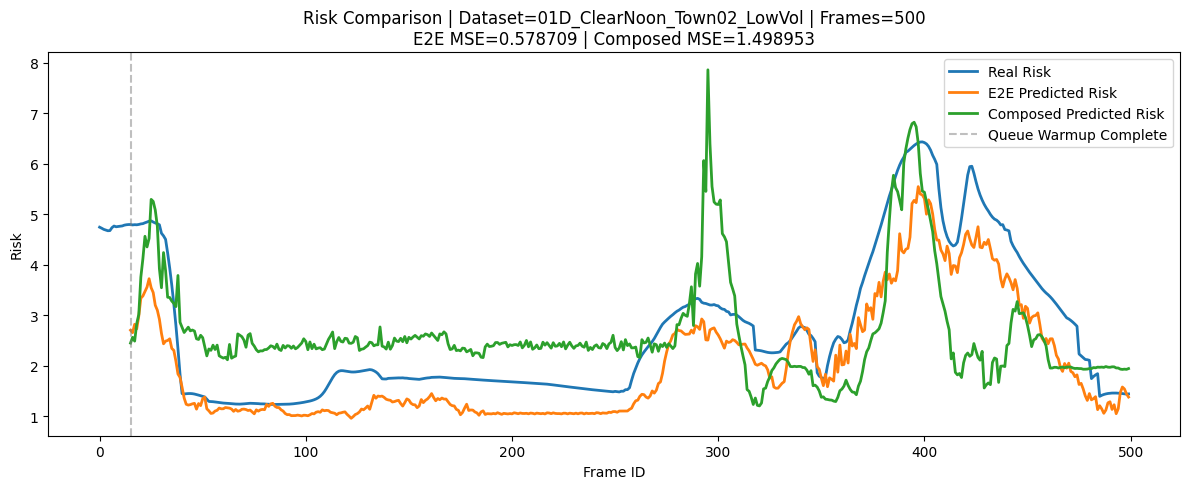

E2E MSE: 0.578709
Composed MSE: 1.498953


In [15]:
def _masked_mse(pred: np.ndarray, target: np.ndarray) -> float:
    mask = np.isfinite(pred) & np.isfinite(target)
    if not np.any(mask):
        return float("nan")
    diff = pred[mask] - target[mask]
    return float(np.mean(diff * diff))

x = np.asarray(used_frame_ids, dtype=np.int64)
real_arr = np.asarray(real_vals, dtype=np.float32)
e2e_arr = np.asarray(e2e_preds, dtype=np.float32)
composed_arr = np.asarray(composed_preds, dtype=np.float32)

e2e_mse = _masked_mse(e2e_arr, real_arr)
composed_mse = _masked_mse(composed_arr, real_arr)

plt.figure(figsize=(12, 5))
plt.plot(x, real_arr, label="Real Risk", linewidth=2)
plt.plot(x, e2e_arr, label="E2E Predicted Risk", linewidth=2)
plt.plot(x, composed_arr, label="Composed Predicted Risk", linewidth=2)

if len(x) >= Config.INFERENCE_SEQUENCE_LENGTH:
    plt.axvline(
        x=x[Config.INFERENCE_SEQUENCE_LENGTH - 1],
        color="gray",
        linestyle="--",
        alpha=0.5,
        label="Queue Warmup Complete",
    )

plt.xlabel("Frame ID")
plt.ylabel("Risk")
plt.title(
    f"Risk Comparison | Dataset={selected_scenario_dir.name} | Frames={len(x)}\n"
    f"E2E MSE={e2e_mse:.6f} | Composed MSE={composed_mse:.6f}"
)
plt.legend()
plt.tight_layout()
plt.show()

print(f"E2E MSE: {e2e_mse:.6f}")
print(f"Composed MSE: {composed_mse:.6f}")